In [1]:
import os
import mne
import numpy as np
# from sentry_sdk.utils import epoch
from sklearn.preprocessing import StandardScaler
import scipy.io as sio
from torch import optim
from typing import List
from torch.utils.data import DataLoader,TensorDataset
from sklearn.metrics import classification_report,confusion_matrix
import torch.nn as nn
import torch
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def calculate_accuracy(loader:DataLoader,model:nn.Module,device:str)->float:
    correct = 0
    total = 0
    with torch.no_grad():
        for datas,labels in loader:
            datas,labels = datas.to(device),labels.to(device)
            outputs = model(datas)
            _,predicted = torch.max(outputs,1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

def get_losses(losses:List[float],loader:DataLoader,model:nn.Module,device:str)->List[float]:
    loss = 0
    with torch.no_grad():
        for i,(inputs,targets)in enumerate(loader):
            inputs,targets = inputs.to(device),targets.to(device)
            outputs = model(inputs)
            l = criterion(outputs,targets)
            loss += l.item()
        loss /= len(loader)
        losses.append(loss)
    return losses
def get_predictions(loader:DataLoader,model:nn.Module,device:str):
    all_targets = []
    all_predictions = []
    with torch.no_grad():
        for i ,(inputs,targets) in enumerate(loader):
            inputs,targets = inputs.to(device),targets.to(device)
            outputs = model(inputs)
            _,predicted = torch.max(outputs,1)
            all_targets.extend(targets.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())
    return all_targets,all_predictions

def loss_curve( epoches : int , train_losses : List[float],val_losses :List[float],model:str = '',folder_path = '',sub = '')->None:
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
    plt.figure(figsize = (10,5))
    plt.plot(range(1,epoches +1),train_losses,label = 'Train Loss')
    plt.plot(range(1,epoches +1),val_losses,label = 'Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('loss')
    plt.title(f'Sub{sub+1} Training and Testing Loss Curve')
    plt.legend()
    img_path = os.path.join(folder_path,'loss_curve.png')
    plt.savefig(img_path)
    plt.show(block = False)
    plt.close()

def plot_confusion_matrix(
        all_train_targets:np.ndarray,
        all_train_predictions:np.ndarray,
        all_test_targets:np.ndarray,
        all_test_predictions:np.ndarray,
        model:str = '',
        folder_path ='',
        sub = ''
)->None:
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)

    plt.figure(figsize = (8,6))
    cm = confusion_matrix(all_train_targets,all_train_predictions)
    sns.heatmap(cm,annot = True,fmt = 'd',cmap = 'Blues',xticklabels = range(2),yticklabels = range(2))
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title(f'Sub{sub+1} Confusion Matrix-Train')
    plt.savefig(os.path.join(folder_path,f'Sub{sub+1} Confusion Matrix-Train'))
    plt.show(block = False)
    plt.close()

    plt.figure(figsize = (8,6))
    cm = confusion_matrix(all_test_targets,all_test_predictions)
    sns.heatmap(cm,annot = True,fmt = 'd',cmap = 'Blues',xticklabels =range(2),yticklabels = range(2))
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title(f'Sub{sub+1} Confusion Matrix-Test')
    plt.savefig(os.path.join(folder_path,f'Sub{sub+1} Confusion Matrix-Test'))
    plt.show(block = False)
    plt.close()

def print_Confusion_matrix(
        all_train_targets:np.ndarray,
        all_train_predictions:np.ndarray,
        all_test_targets:np.ndarray,
        all_test_predictions:np.ndarray,
        model:str = '',
        folder_path ='',
        sub = ''
):
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)

    report_train = classification_report(all_train_targets,all_train_predictions)
    report_test  = classification_report(all_test_targets, all_test_predictions)

    with open(os.path.join(folder_path,f'Sub{sub+1}Report.txt'),'w')as f:
        f.write('\nReport Train')
        f.write(report_train)
        f.write('\nReport Test')
        f.write(report_test)

In [6]:
class EEGNet(nn.Module):
    # def __init__(self, n_classes=4, channels=22, samples=1000,
    #              dropoutRate=0.5, kernelLength=32, kernelLength2=16,
    #              F1=16, D=2, F2=32):
    def __init__(self, n_classes=2, channels=30, samples=384,
                     drop_out=0.5, kernelLength=32, kernelLength2=16,
                     F1=16, D=2, F2=32):
        super(EEGNet, self).__init__()
        self.n_classes = n_classes
        self.channels = channels
        self.samples = samples
        # self.drop_out = dropoutRate
        self.drop_out = drop_out
        self.kernelLength = kernelLength
        self.kernelLength2 = kernelLength2
        self.F1 = F1
        self.D = D
        self.F2 = F2

        block1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=self.F1,
                      kernel_size=(1,self.kernelLength), stride=1,
                      padding=(0,self.kernelLength//2),
                      bias=False
        ),
            nn.BatchNorm2d(num_features=self.F1)
        )

        block2 = nn.Sequential(
            nn.Conv2d(in_channels=self.F1,out_channels=self.F1*self.D,
                      kernel_size=(self.channels,1), groups=self.F1,
                      bias=False
                      ),
            nn.BatchNorm2d(num_features=self.F1*self.D),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1,8)),
            nn.Dropout(p=self.drop_out)
        )

        block3 = nn.Sequential(
            nn.Conv2d(in_channels=self.F1*self.D,out_channels=self.F2,
                      kernel_size=(1,self.kernelLength2), stride=1,
                      padding=(0,self.kernelLength2//2),groups=self.F1*self.D,
                      bias=False
                      ),
            nn.Conv2d(in_channels=self.F2,out_channels=self.F2,
                      kernel_size=(1,1), stride=1,
                      bias=False),
            nn.BatchNorm2d(num_features=self.F2),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1,16)),
            nn.Dropout(p=self.drop_out)
        )

        self.EEGNetLayer = nn.Sequential(block1, block2, block3)
        # self.FlattenLayer = nn.Flatten()
        self.ClassifierBlock = nn.Sequential(nn.Linear(in_features=self.F2 * round((self.samples // 8) // 16),
                                                       out_features=self.n_classes,
                                                       bias=False),
                                             nn.Softmax(dim=1)
        )
        # self.model = nn.Sequential(self.EEGNetLayer, self.FlattenLayer, self.ClassifierBlock)
    def forward(self, x):
        if len(x.shape) != 4:
            x = torch.unsqueeze(x,1)
        x = self.EEGNetLayer(x)
        x = x.view(x.size()[0], -1)  # Flatten # [N, self.F2*1*T/32]
        x = self.ClassifierBlock(x)
        # x = self.model(x)

        return x

In [4]:
file = sio.loadmat(f'dataset.mat')

EEGsample = file['EEGsample']
subindex = file['subindex']
substate = file['substate']


In [5]:
save_path = os.path.join(os.getcwd(), 'results')
if not os.path.exists(save_path):
    os.makedirs(save_path)

path = os.path.join(save_path, 'EEGNet')
if not os.path.exists(path):
    os.makedirs(path)
report_path = os.path.join(path, 'report.txt')

torch.manual_seed(2024)


========== 开始第 1/11 折LOOCV（测试序号：0）==========
Fold [1/11], Epoch [1/500], Step [1/8], Loss: 0.6937
Fold [1/11], Epoch [101/500], Step [1/8], Loss: 0.4538
Fold [1/11], Epoch [201/500], Step [1/8], Loss: 0.4307
Fold [1/11], Epoch [301/500], Step [1/8], Loss: 0.4258
Fold [1/11], Epoch [401/500], Step [1/8], Loss: 0.4060


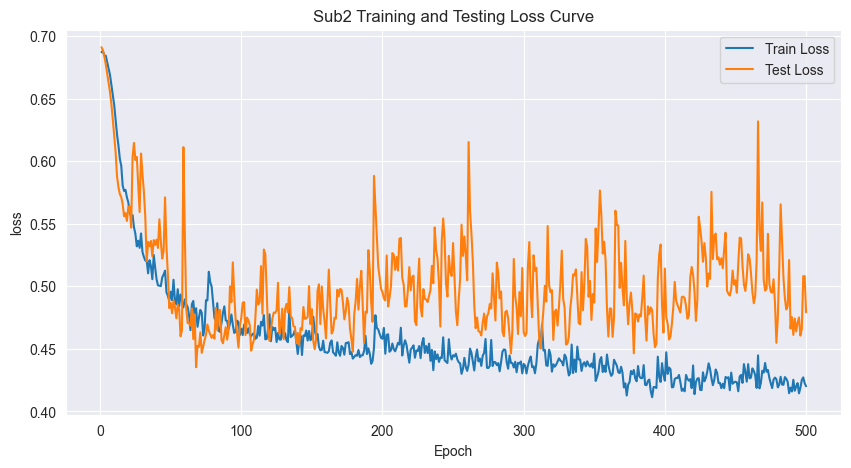

<Figure size 640x480 with 0 Axes>

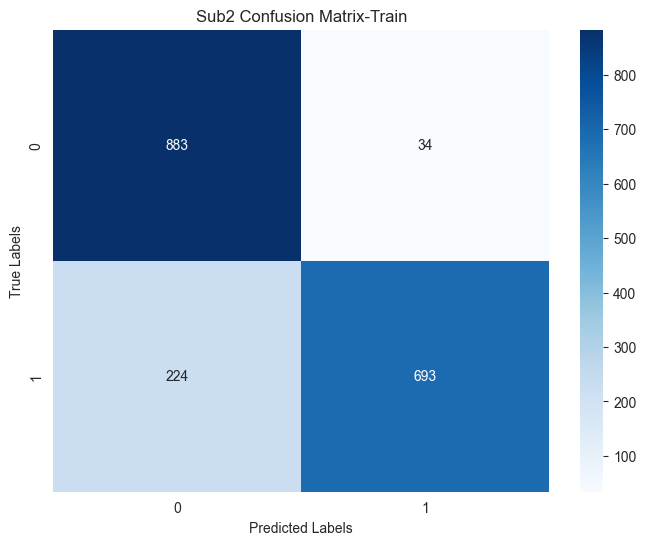

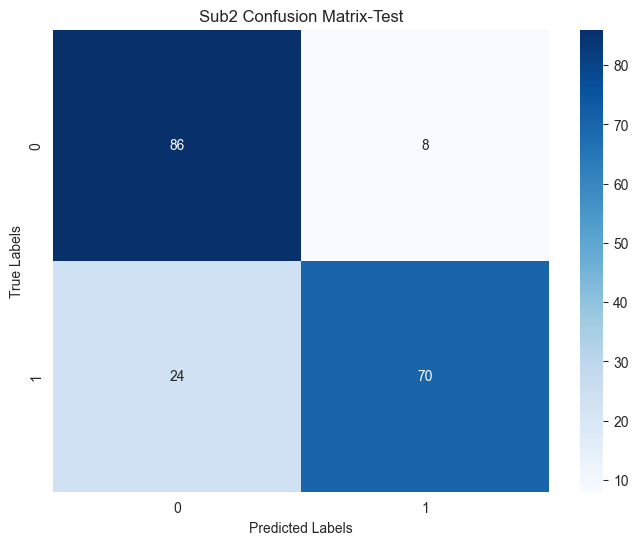

第 1 折（测试序号0）Acc: 82.98%

========== 开始第 2/11 折LOOCV（测试序号：1）==========
Fold [2/11], Epoch [1/500], Step [1/8], Loss: 0.6985
Fold [2/11], Epoch [101/500], Step [1/8], Loss: 0.4542
Fold [2/11], Epoch [201/500], Step [1/8], Loss: 0.4109
Fold [2/11], Epoch [301/500], Step [1/8], Loss: 0.4450
Fold [2/11], Epoch [401/500], Step [1/8], Loss: 0.4093


<Figure size 640x480 with 0 Axes>

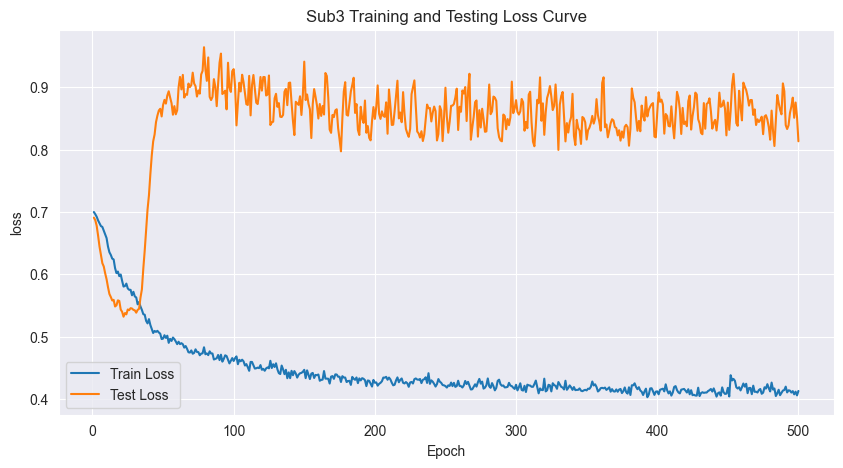

<Figure size 640x480 with 0 Axes>

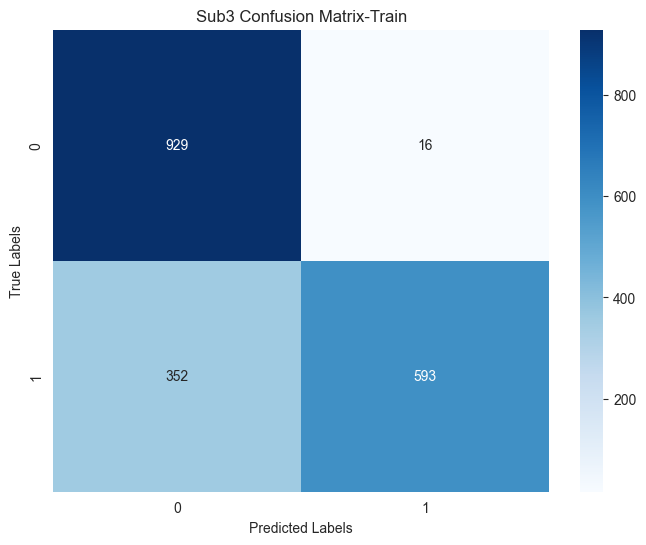

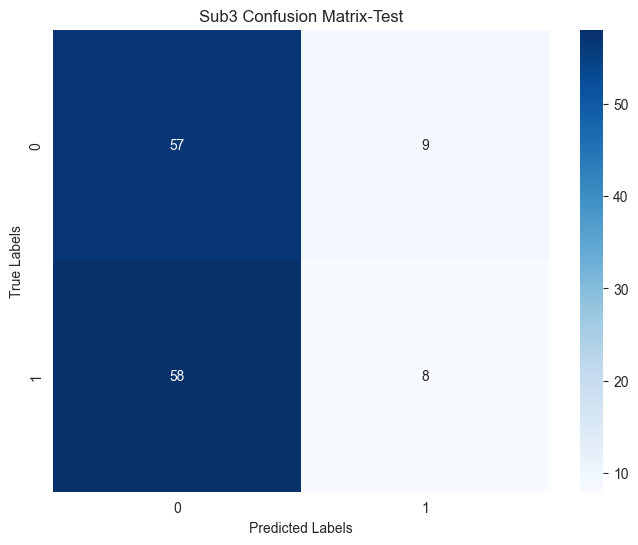

第 2 折（测试序号1）Acc: 49.24%

========== 开始第 3/11 折LOOCV（测试序号：2）==========
Fold [3/11], Epoch [1/500], Step [1/8], Loss: 0.6884
Fold [3/11], Epoch [101/500], Step [1/8], Loss: 0.4307
Fold [3/11], Epoch [201/500], Step [1/8], Loss: 0.4344
Fold [3/11], Epoch [301/500], Step [1/8], Loss: 0.4123
Fold [3/11], Epoch [401/500], Step [1/8], Loss: 0.4073


<Figure size 640x480 with 0 Axes>

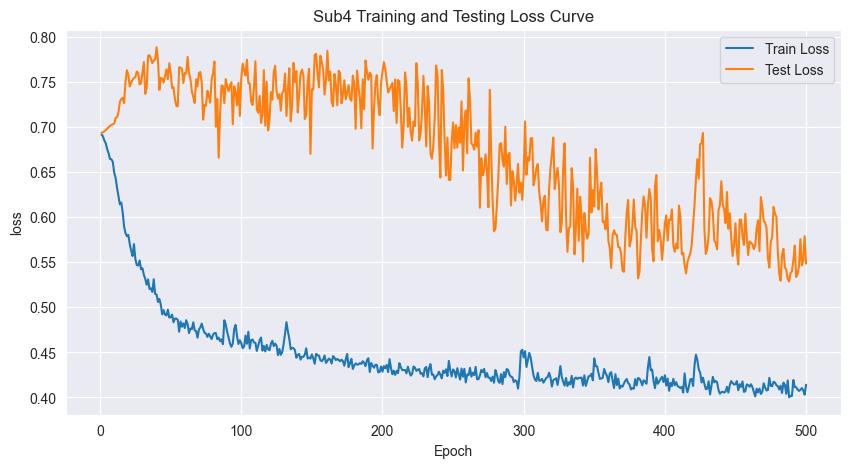

<Figure size 640x480 with 0 Axes>

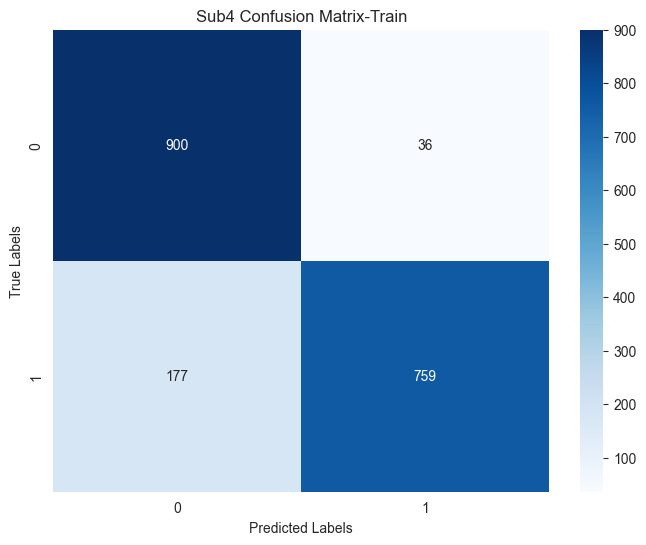

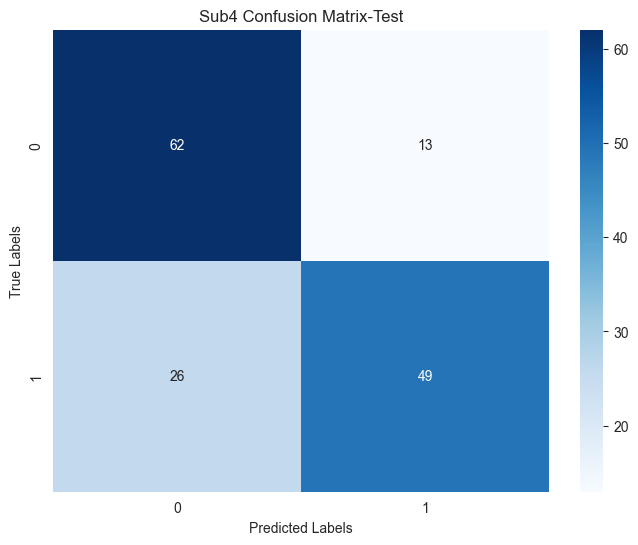

第 3 折（测试序号2）Acc: 74.00%

========== 开始第 4/11 折LOOCV（测试序号：3）==========
Fold [4/11], Epoch [1/500], Step [1/8], Loss: 0.6820
Fold [4/11], Epoch [101/500], Step [1/8], Loss: 0.4388
Fold [4/11], Epoch [201/500], Step [1/8], Loss: 0.4573
Fold [4/11], Epoch [301/500], Step [1/8], Loss: 0.4046
Fold [4/11], Epoch [401/500], Step [1/8], Loss: 0.4299


<Figure size 640x480 with 0 Axes>

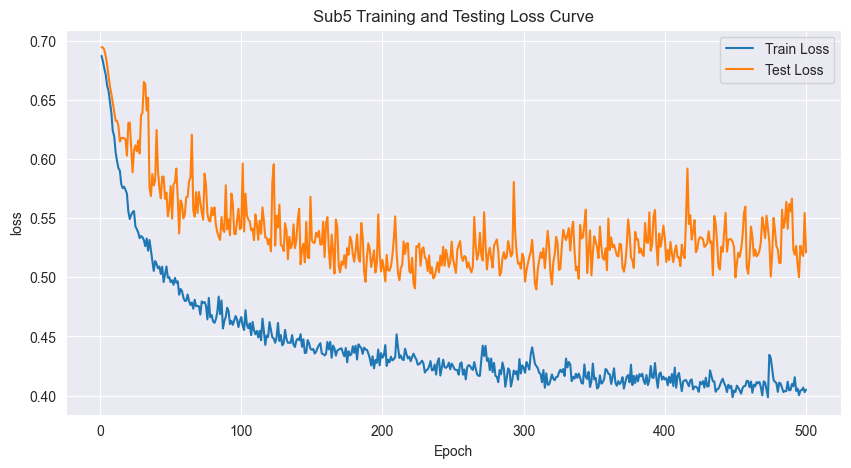

<Figure size 640x480 with 0 Axes>

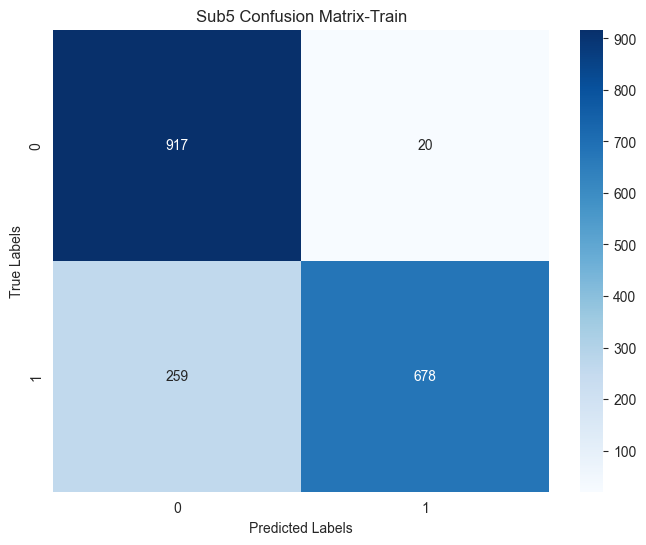

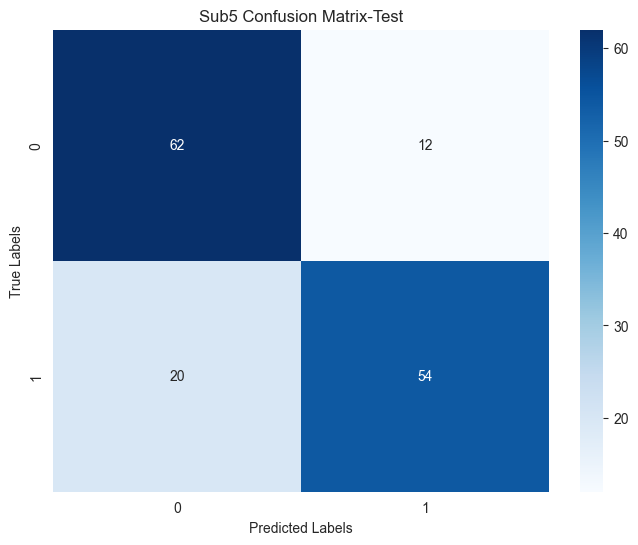

第 4 折（测试序号3）Acc: 78.38%

========== 开始第 5/11 折LOOCV（测试序号：4）==========
Fold [5/11], Epoch [1/500], Step [1/8], Loss: 0.6901
Fold [5/11], Epoch [101/500], Step [1/8], Loss: 0.4955
Fold [5/11], Epoch [201/500], Step [1/8], Loss: 0.4666
Fold [5/11], Epoch [301/500], Step [1/8], Loss: 0.4676
Fold [5/11], Epoch [401/500], Step [1/8], Loss: 0.4365


<Figure size 640x480 with 0 Axes>

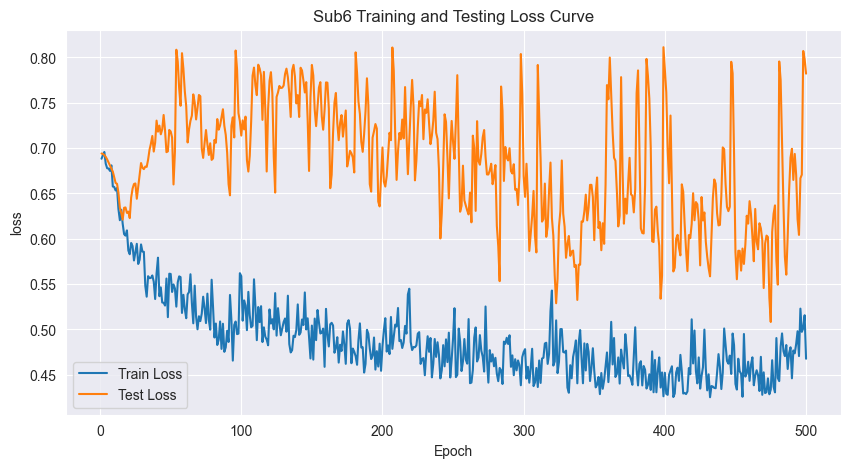

<Figure size 640x480 with 0 Axes>

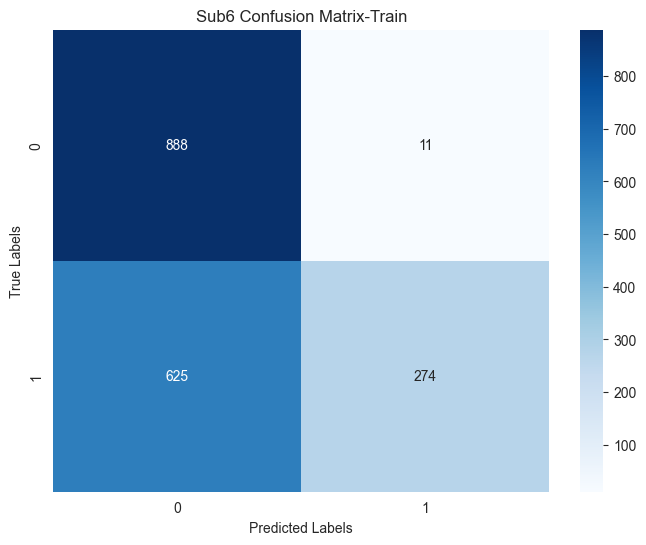

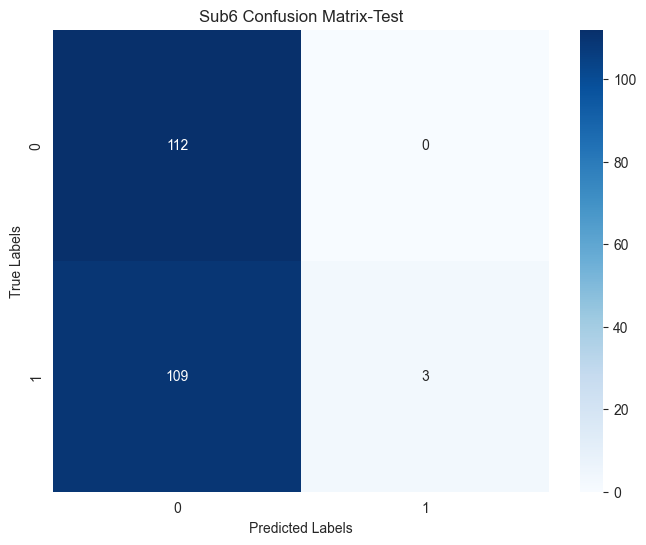

第 5 折（测试序号4）Acc: 51.34%

========== 开始第 6/11 折LOOCV（测试序号：5）==========
Fold [6/11], Epoch [1/500], Step [1/8], Loss: 0.6847
Fold [6/11], Epoch [101/500], Step [1/8], Loss: 0.4753
Fold [6/11], Epoch [201/500], Step [1/8], Loss: 0.4377
Fold [6/11], Epoch [301/500], Step [1/8], Loss: 0.4224
Fold [6/11], Epoch [401/500], Step [1/8], Loss: 0.4296


<Figure size 640x480 with 0 Axes>

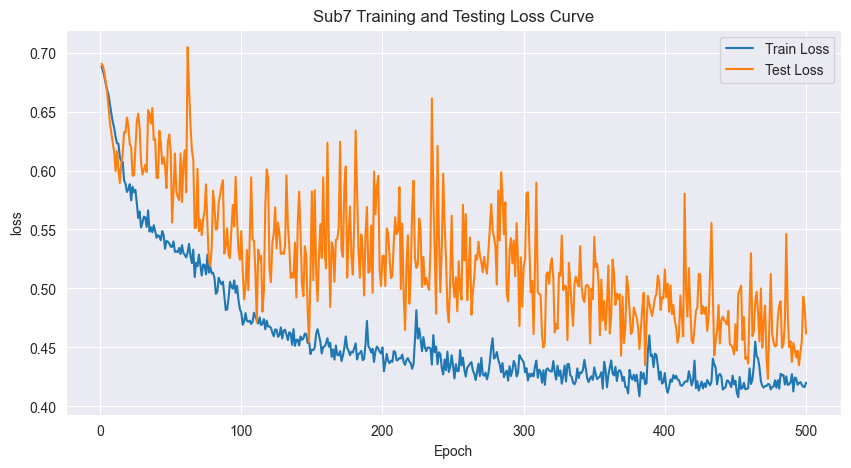

<Figure size 640x480 with 0 Axes>

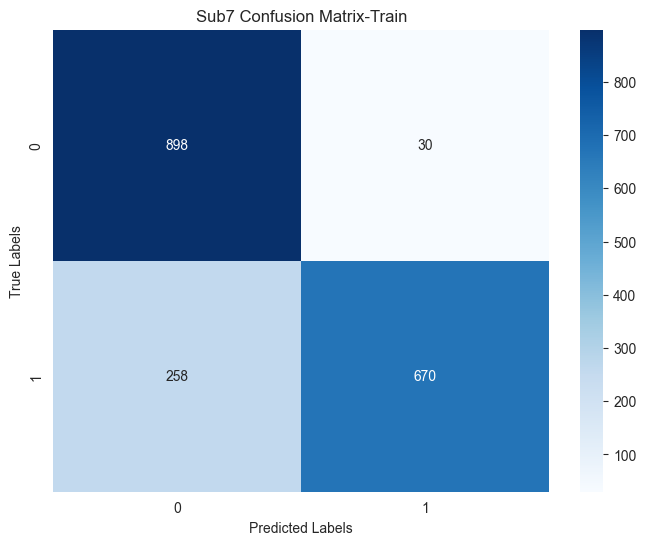

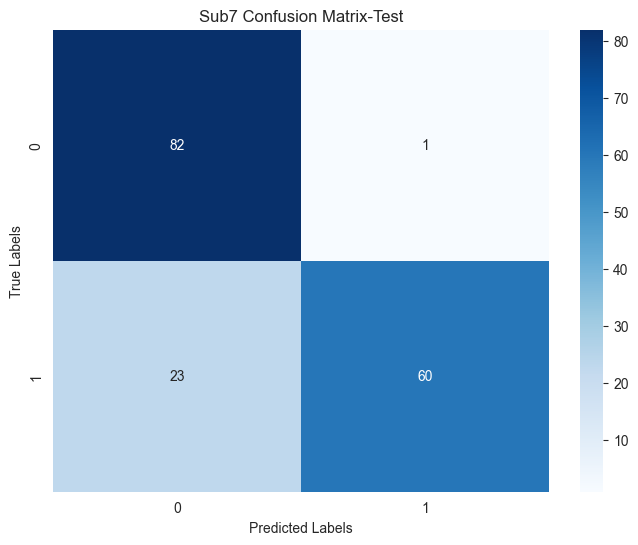

第 6 折（测试序号5）Acc: 85.54%

========== 开始第 7/11 折LOOCV（测试序号：6）==========
Fold [7/11], Epoch [1/500], Step [1/8], Loss: 0.6871
Fold [7/11], Epoch [101/500], Step [1/8], Loss: 0.4360
Fold [7/11], Epoch [201/500], Step [1/8], Loss: 0.4530
Fold [7/11], Epoch [301/500], Step [1/8], Loss: 0.4210
Fold [7/11], Epoch [401/500], Step [1/8], Loss: 0.4092


<Figure size 640x480 with 0 Axes>

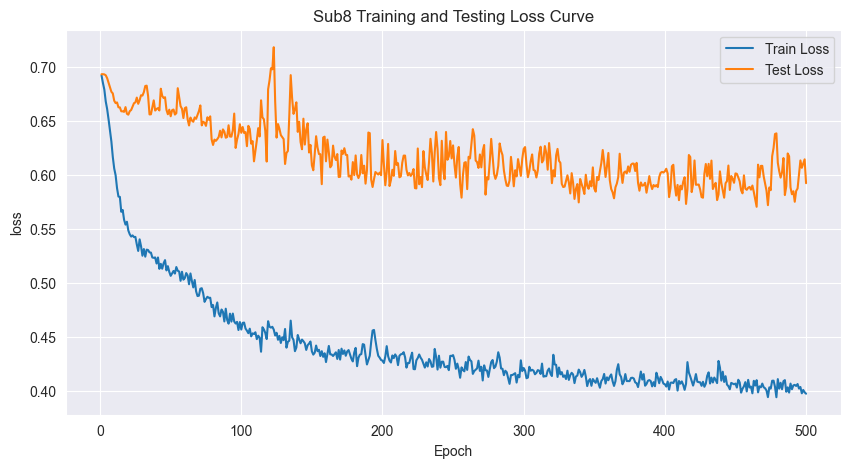

<Figure size 640x480 with 0 Axes>

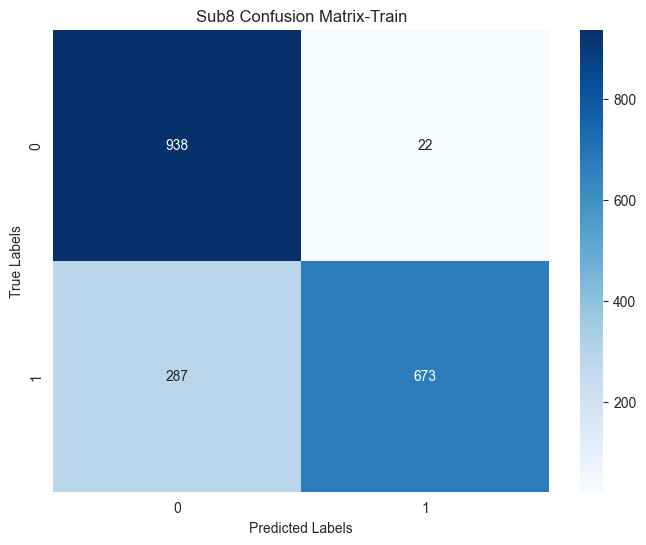

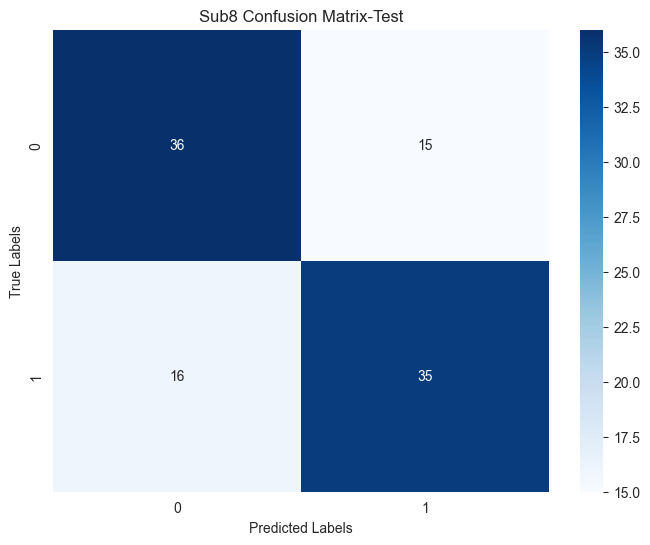

第 7 折（测试序号6）Acc: 69.61%

========== 开始第 8/11 折LOOCV（测试序号：7）==========
Fold [8/11], Epoch [1/500], Step [1/7], Loss: 0.6870
Fold [8/11], Epoch [101/500], Step [1/7], Loss: 0.4736
Fold [8/11], Epoch [201/500], Step [1/7], Loss: 0.4423
Fold [8/11], Epoch [301/500], Step [1/7], Loss: 0.4160
Fold [8/11], Epoch [401/500], Step [1/7], Loss: 0.4189


<Figure size 640x480 with 0 Axes>

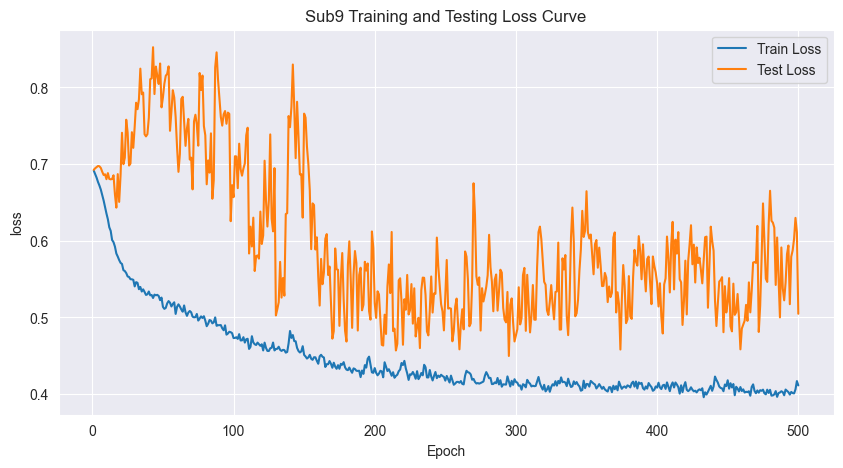

<Figure size 640x480 with 0 Axes>

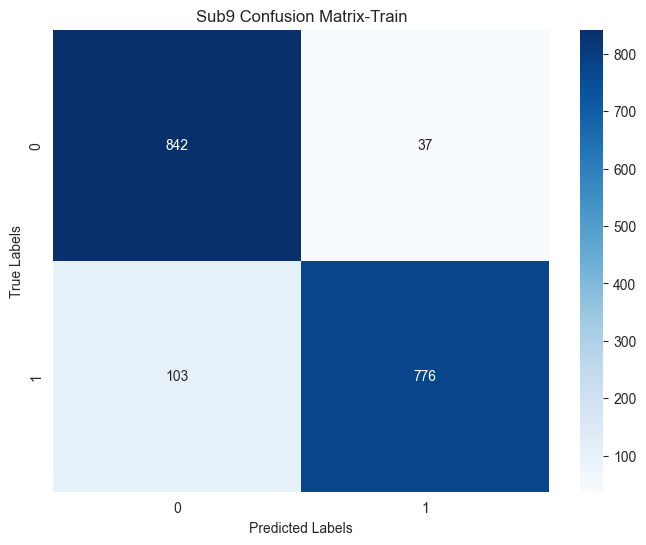

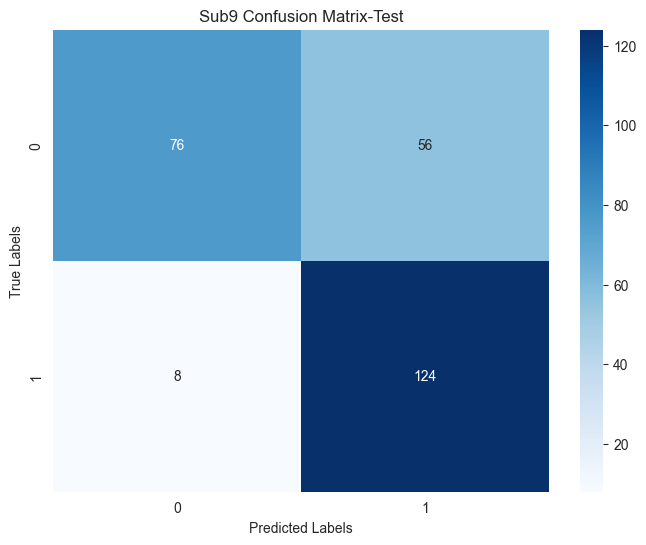

第 8 折（测试序号7）Acc: 75.76%

========== 开始第 9/11 折LOOCV（测试序号：8）==========
Fold [9/11], Epoch [1/500], Step [1/7], Loss: 0.6867
Fold [9/11], Epoch [101/500], Step [1/7], Loss: 0.4685
Fold [9/11], Epoch [201/500], Step [1/7], Loss: 0.4114
Fold [9/11], Epoch [301/500], Step [1/7], Loss: 0.4132
Fold [9/11], Epoch [401/500], Step [1/7], Loss: 0.4168


<Figure size 640x480 with 0 Axes>

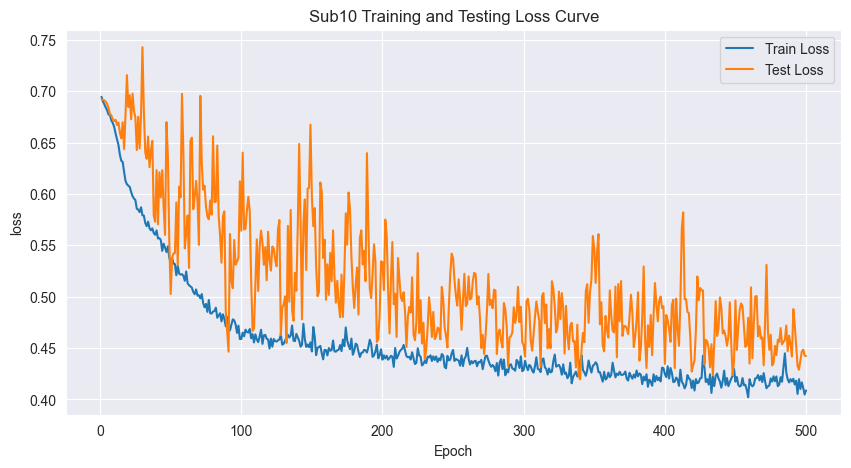

<Figure size 640x480 with 0 Axes>

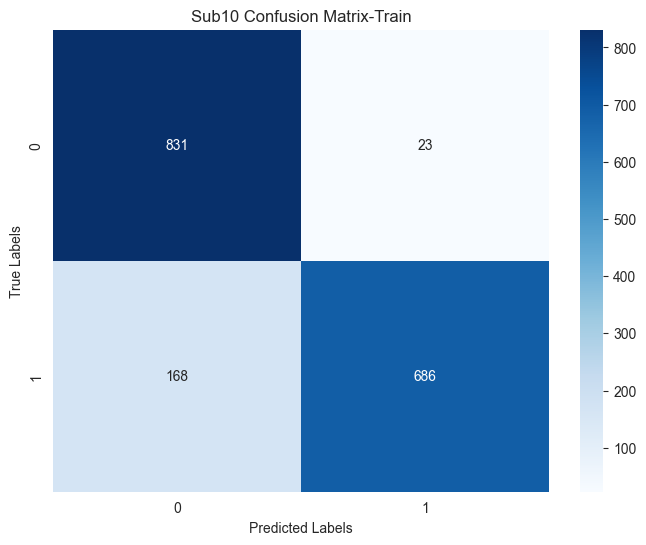

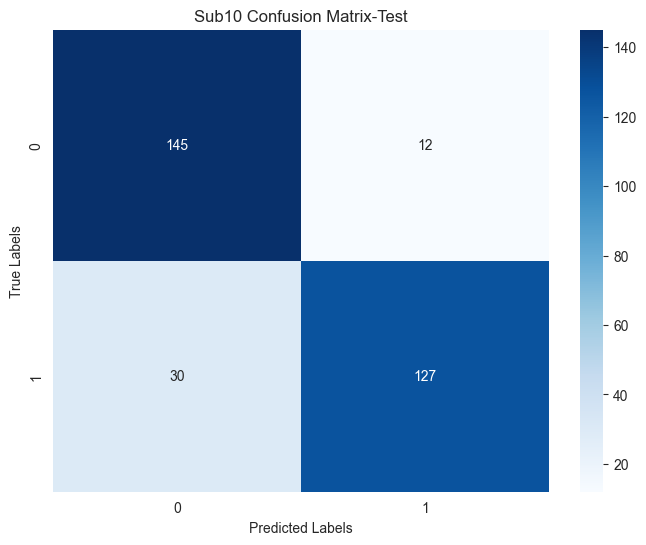

第 9 折（测试序号8）Acc: 86.62%

========== 开始第 10/11 折LOOCV（测试序号：9）==========
Fold [10/11], Epoch [1/500], Step [1/8], Loss: 0.7113
Fold [10/11], Epoch [101/500], Step [1/8], Loss: 0.4380
Fold [10/11], Epoch [201/500], Step [1/8], Loss: 0.4430
Fold [10/11], Epoch [301/500], Step [1/8], Loss: 0.3990
Fold [10/11], Epoch [401/500], Step [1/8], Loss: 0.3956


<Figure size 640x480 with 0 Axes>

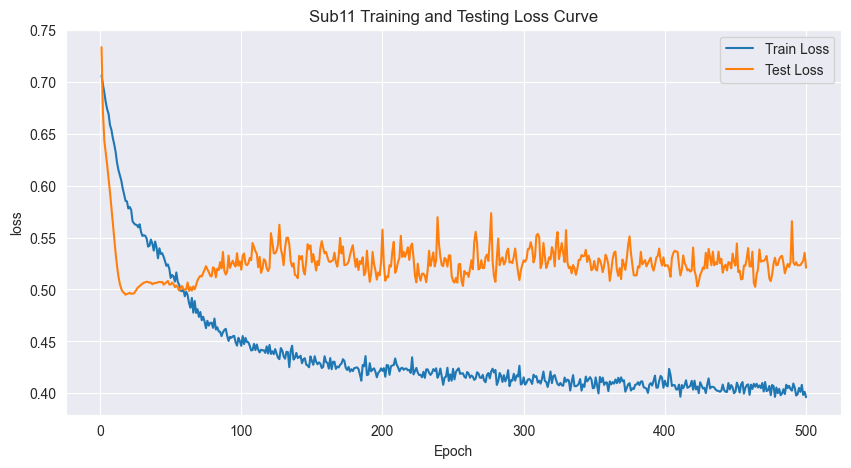

<Figure size 640x480 with 0 Axes>

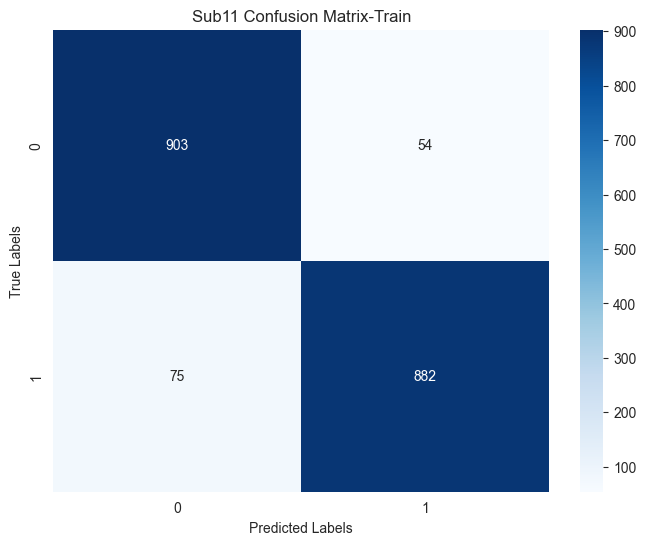

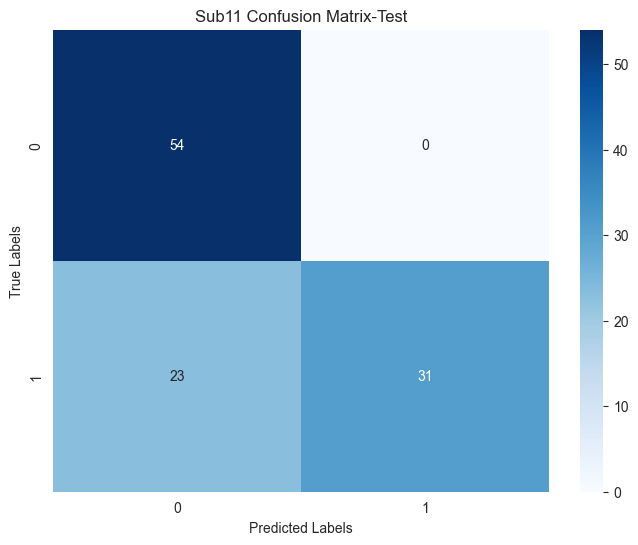

第 10 折（测试序号9）Acc: 78.70%

========== 开始第 11/11 折LOOCV（测试序号：10）==========
Fold [11/11], Epoch [1/500], Step [1/8], Loss: 0.6999
Fold [11/11], Epoch [101/500], Step [1/8], Loss: 0.4722
Fold [11/11], Epoch [201/500], Step [1/8], Loss: 0.4361
Fold [11/11], Epoch [301/500], Step [1/8], Loss: 0.4319
Fold [11/11], Epoch [401/500], Step [1/8], Loss: 0.5091


<Figure size 640x480 with 0 Axes>

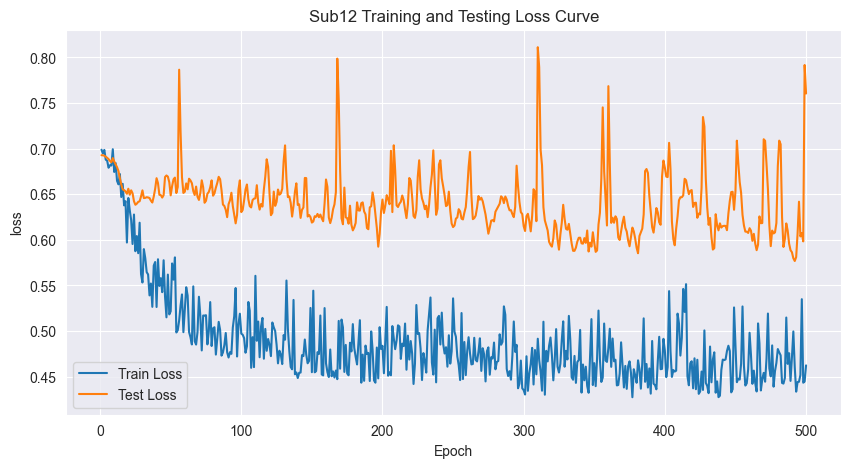

<Figure size 640x480 with 0 Axes>

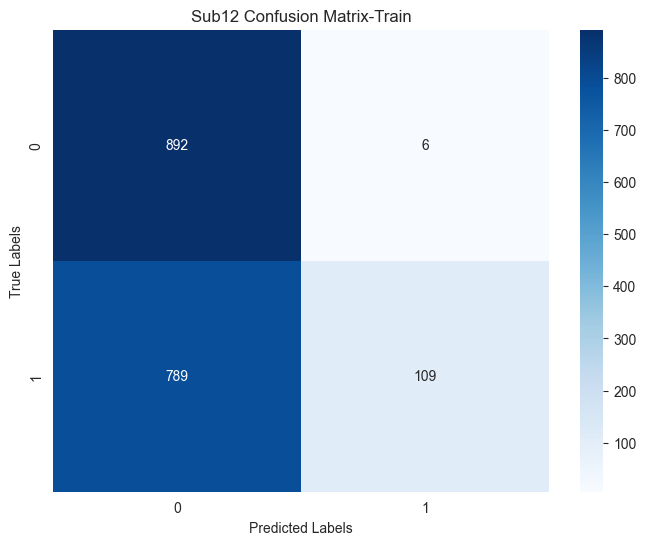

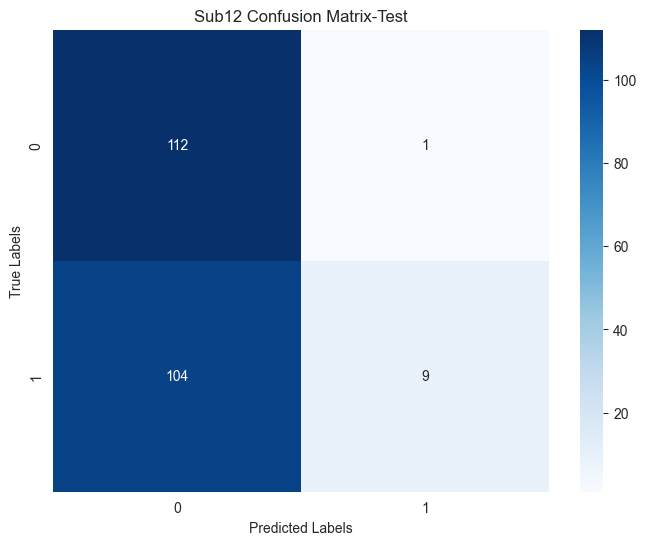

第 11 折（测试序号10）Acc: 53.54%

========== LOOCV最终结果 ==========
11折平均测试准确率: 71.43% (标准差: 13.17%)


<Figure size 640x480 with 0 Axes>

In [7]:
datas = []
test_datas = []

# 定义超参数（保持不变）
lr = 0.01
wd = 0.001
bs = 256
op = 'SGD'
dr = 0.5
epoches = 500
all_loocv_accuracies = []  # 新增：保存11次LOOCV的准确率
all_loocv_train_losses = []  # 新增：保存11次的训练损失
all_loocv_test_losses = []   # 新增：保存11次的测试损失

# 原始数据处理（保持不变）
predata = torch.Tensor(EEGsample)
label = torch.Tensor(substate).long()
index = torch.Tensor(subindex).long() - 1 # index是0-10
inpt = predata.reshape(-1, 1, 30, 384) # (2022,1,30,384)

# 提取所有唯一的样本序号（0-10），共11个
unique_index = torch.unique(index).numpy()
n_folds = len(unique_index)  # LOOCV的折数=11

# ====================== 核心：LOOCV循环 ======================
for fold_idx, test_idx in enumerate(unique_index):
    print(f"\n========== 开始第 {fold_idx+1}/{n_folds} 折LOOCV（测试序号：{test_idx}）==========")

    # 1. 划分本次LOOCV的训练/测试序号
    train_index_ids = [idx for idx in unique_index if idx != test_idx]  # 剩余10个作为训练
    test_index_ids = [test_idx]  # 留1个作为测试

    # 2. 生成训练/测试掩码（兼容低版本PyTorch）
    # 训练掩码
    train_mask = torch.zeros_like(index, dtype=torch.bool)
    for idx in train_index_ids:
        train_mask = train_mask | (index == idx)
    # 测试掩码
    test_mask = torch.zeros_like(index, dtype=torch.bool)
    test_mask = test_mask | (index == test_idx)

    # 3. 拆分训练/测试数据
    train_inpt = inpt[train_mask]
    train_label = label[train_mask]
    test_inpt = inpt[test_mask]
    test_label = label[test_mask]

    # 4. 构建数据集和DataLoader
    train_dataset = TensorDataset(train_inpt, train_label)
    test_dataset = TensorDataset(test_inpt, test_label)
    train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=bs, shuffle=False)

    # 5. 重新初始化模型/优化器（关键！LOOCV每次必须重新初始化）
    # device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # device = torch.device("cpu")  # 强制CPU
    net = EEGNet(drop_out = dr).to(device)

    criterion = nn.CrossEntropyLoss().to(device)
    if op == 'Adam':
        optimizer = optim.Adam(net.parameters(),lr = lr,weight_decay=wd)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epoches, eta_min=0)
    else:
        optimizer = optim.SGD(net.parameters(),lr = lr,weight_decay=wd,momentum=0.9,nesterov=True)

    # 初始化本次折的损失记录
    train_losses = []
    test_losses = []

    # 6. 训练模型（和你原有训练逻辑一致）
    for epoch in range(epoches):
        net.train()
        train_loss = 0.0

        for i, (inputs, targets) in enumerate(train_loader):
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = net(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            if op == 'Adam':
                scheduler.step()

            # 打印日志（仅每100epoch+每10step）
            if epoch%100==0 and i %10==0:
                print(f'Fold [{fold_idx+1}/{n_folds}], Epoch [{epoch+1}/{epoches}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}')
            train_loss += loss.item()

        # 验证阶段
        net.eval()
        train_loss /= len(train_loader)
        train_losses.append(train_loss)
        test_losses = get_losses(test_losses, test_loader, net, device)

    # 7. 评估本次折的模型
    net.eval()
    # 获取预测结果
    all_train_targets, all_train_predictions = get_predictions(train_loader, net, device)
    all_test_targets, all_test_predictions = get_predictions(test_loader, net, device)

    # 保存本次折的损失/可视化（可选，按需求调整路径）
    sub_path = os.path.join(path, 'EEGNet', f'fold_{fold_idx+1}_testidx_{test_idx}')
    os.makedirs(sub_path, exist_ok=True)
    loss_curve(epoches, train_losses, test_losses, folder_path=sub_path, sub=fold_idx+1)
    plt.clf()
    plot_confusion_matrix(all_train_targets,all_train_predictions,all_test_targets,all_test_predictions,folder_path=sub_path, sub=fold_idx+1)
    plt.clf()

    # 计算本次折的准确率
    test_accuracy = calculate_accuracy(test_loader, net, device)
    all_loocv_accuracies.append(test_accuracy)
    print(f'第 {fold_idx+1} 折（测试序号{test_idx}）Acc: {test_accuracy:.2f}%')

    # 保存本次折的损失
    all_loocv_train_losses.append(train_losses)
    all_loocv_test_losses.append(test_losses)

    # 写入单次折的结果到报告
    with open(report_path, 'a') as f:
        f.write(f'LOOCV Fold {fold_idx+1}（测试序号{test_idx}）Acc: {test_accuracy:.2f}%\n')

# ====================== LOOCV结束：计算最终结果 ======================
# 计算11次折的平均准确率
mean_loocv_accuracy = np.mean(all_loocv_accuracies)
std_loocv_accuracy = np.std(all_loocv_accuracies)  # 标准差，评估稳定性
print(f"\n========== LOOCV最终结果 ==========")
print(f'11折平均测试准确率: {mean_loocv_accuracy:.2f}% (标准差: {std_loocv_accuracy:.2f}%)')

# 写入最终结果到报告
with open(report_path, 'a') as f:
    f.write(f'\nLOOCV 11折平均准确率: {mean_loocv_accuracy:.2f}% (标准差: {std_loocv_accuracy:.2f}%)\n')
    f.write(f'各折准确率: {[f"{acc:.2f}%" for acc in all_loocv_accuracies]}\n')